# How to train your model

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency


## Generate dataset

In [2]:
# Load training data
df = pd.read_csv(
    "adult.csv",
    na_values='?'
)
df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Split to train test

In [3]:
from sklearn.model_selection import train_test_split

df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['income']
)

## Explore the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39073 entries, 34342 to 42656
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              39073 non-null  int64 
 1   workclass        36849 non-null  object
 2   fnlwgt           39073 non-null  int64 
 3   education        39073 non-null  object
 4   educational-num  39073 non-null  int64 
 5   marital-status   39073 non-null  object
 6   occupation       36839 non-null  object
 7   relationship     39073 non-null  object
 8   race             39073 non-null  object
 9   gender           39073 non-null  object
 10  capital-gain     39073 non-null  int64 
 11  capital-loss     39073 non-null  int64 
 12  hours-per-week   39073 non-null  int64 
 13  native-country   38392 non-null  object
 14  income           39073 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.8+ MB


### How many missing values in each column

In [5]:
df.isna().sum()

age                   0
workclass          2224
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2234
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      681
income                0
dtype: int64

### Seperate numeriacl columns from categorial

In [6]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:")
print(list(num_cols))

print("\nCategorical columns:")
print(list(cat_cols))


Numerical columns:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


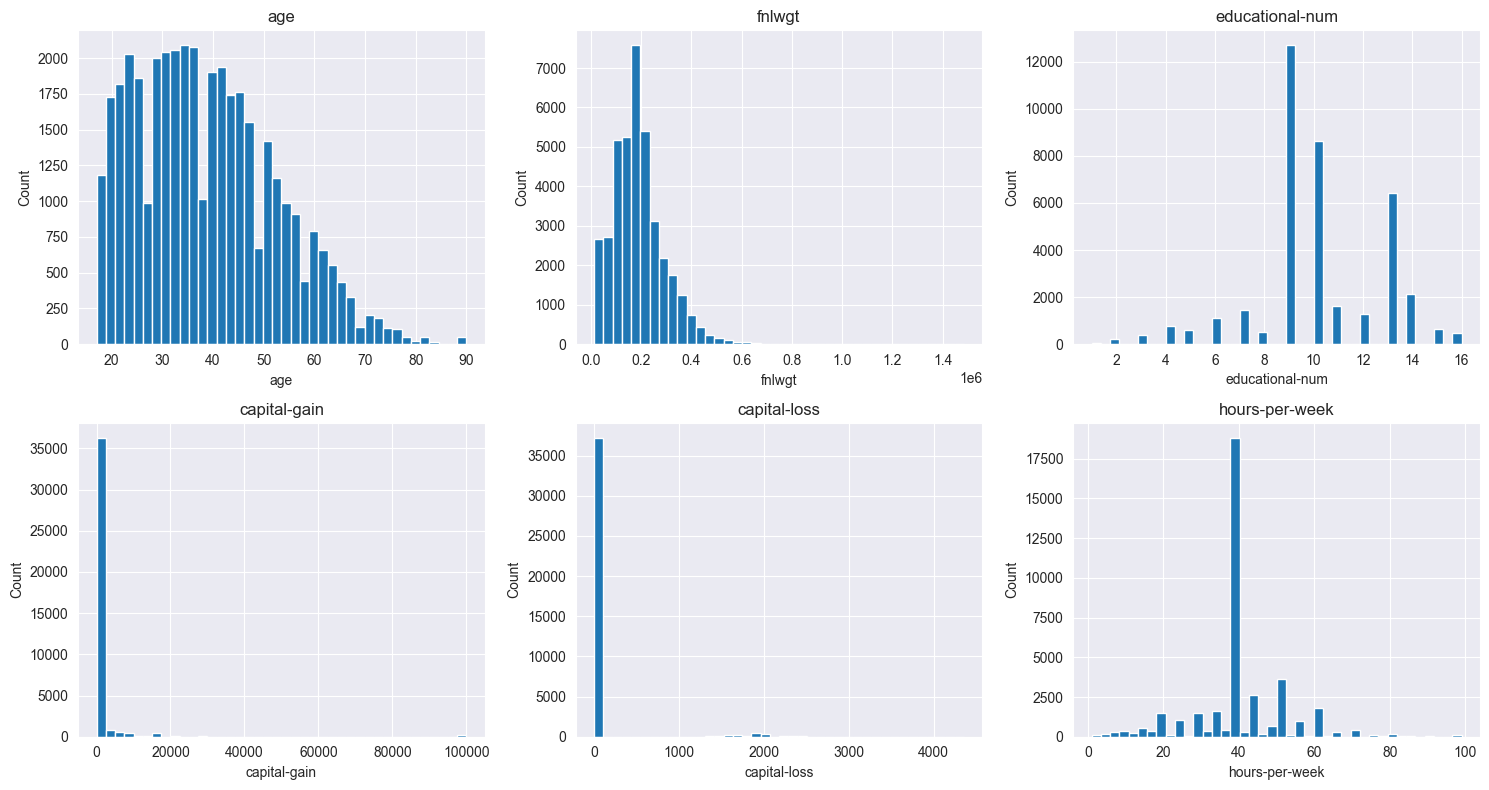

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Turn off unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [8]:
capital_gain_0_frac = (df["capital-gain"] == 0).sum() / df.shape[0]
print(f"capital gain: {capital_gain_0_frac:.2f}%")

capital_loss_0_frac = (df["capital-loss"] == 0).sum() / df.shape[0]
print(f"capital loss: {capital_loss_0_frac:.2f}%")


capital gain: 0.92%
capital loss: 0.95%


In [9]:
def plot_cat(df):
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        df[col].value_counts().plot(kind="bar", ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    # turn off unused axes
    for j in range(len(cat_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


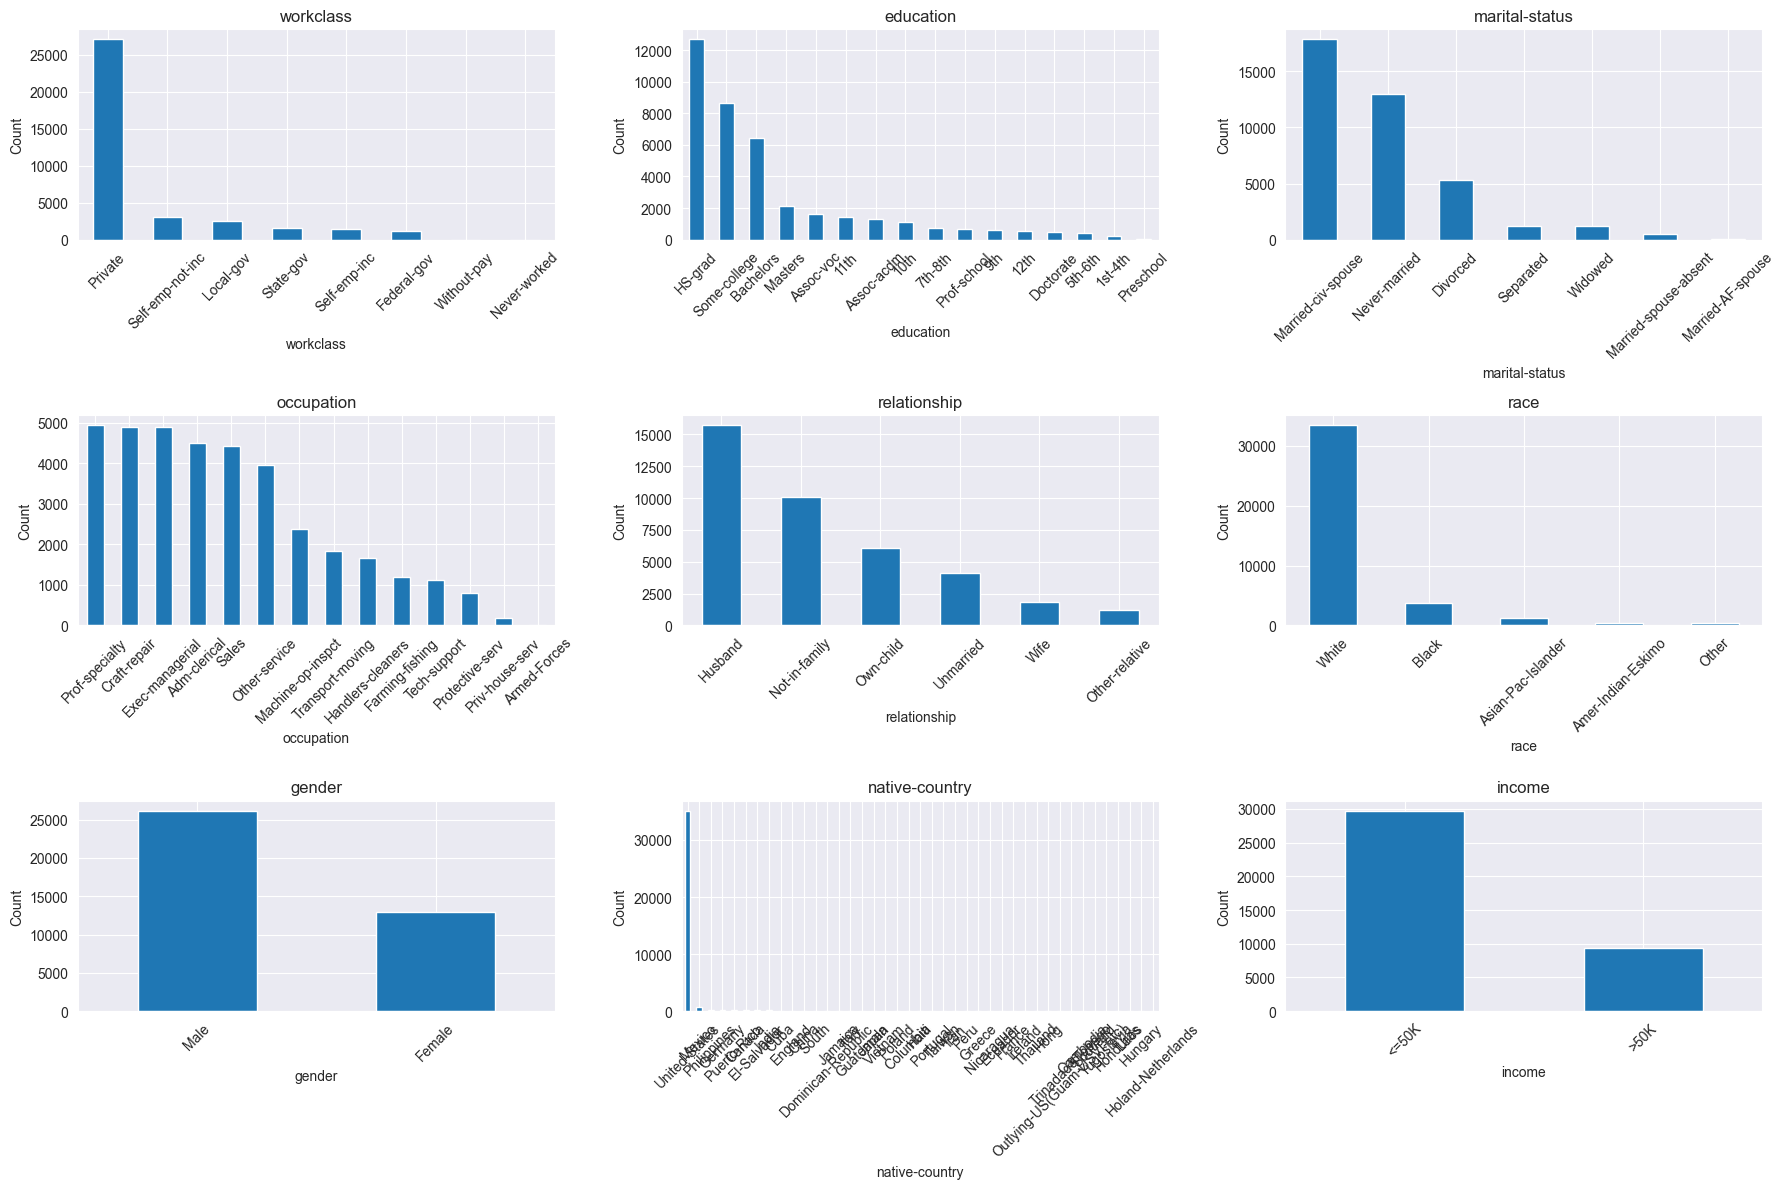

In [10]:
plot_cat(df)

In [11]:
native_country_frac = (df["native-country"] == 'United-States').sum() / df.shape[0]
print(f"native country: {native_country_frac:.2f}%")


native country: 0.90%


In [12]:
df.drop(columns=["native-country", "capital-gain", "capital-loss"], inplace=True)

In [13]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0


def correlation_ratio(categories, values):
    categories = np.asarray(categories)
    values = np.asarray(values)

    mask = ~pd.isna(categories) & ~pd.isna(values)
    categories = categories[mask]
    values = values[mask]

    mean_total = np.mean(values)
    ss_total = np.sum((values - mean_total) ** 2)

    ss_between = 0.0
    for cat in np.unique(categories):
        v = values[categories == cat]
        ss_between += len(v) * (np.mean(v) - mean_total) ** 2

    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0.0


In [14]:
def plot_heatmap(df):
    cols = df.columns
    assoc = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1 in cols:
        for c2 in cols:
            x, y = df[c1], df[c2]

            x_num = pd.api.types.is_numeric_dtype(x)
            y_num = pd.api.types.is_numeric_dtype(y)

            if x_num and y_num:
                assoc.loc[c1, c2] = x.corr(y, method="pearson")

            elif (not x_num) and (not y_num):
                assoc.loc[c1, c2] = cramers_v(x, y)

            elif x_num and not y_num:
                assoc.loc[c1, c2] = correlation_ratio(y.astype(str), x)

            else:  # not x_num and y_num
                assoc.loc[c1, c2] = correlation_ratio(x.astype(str), y)

    plt.figure(figsize=(15, 13))
    sns.heatmap(
        assoc,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        cbar_kws={"label": "Association strength"}
    )
    plt.title("Full Feature × Feature Association Matrix")
    plt.tight_layout()
    plt.show()


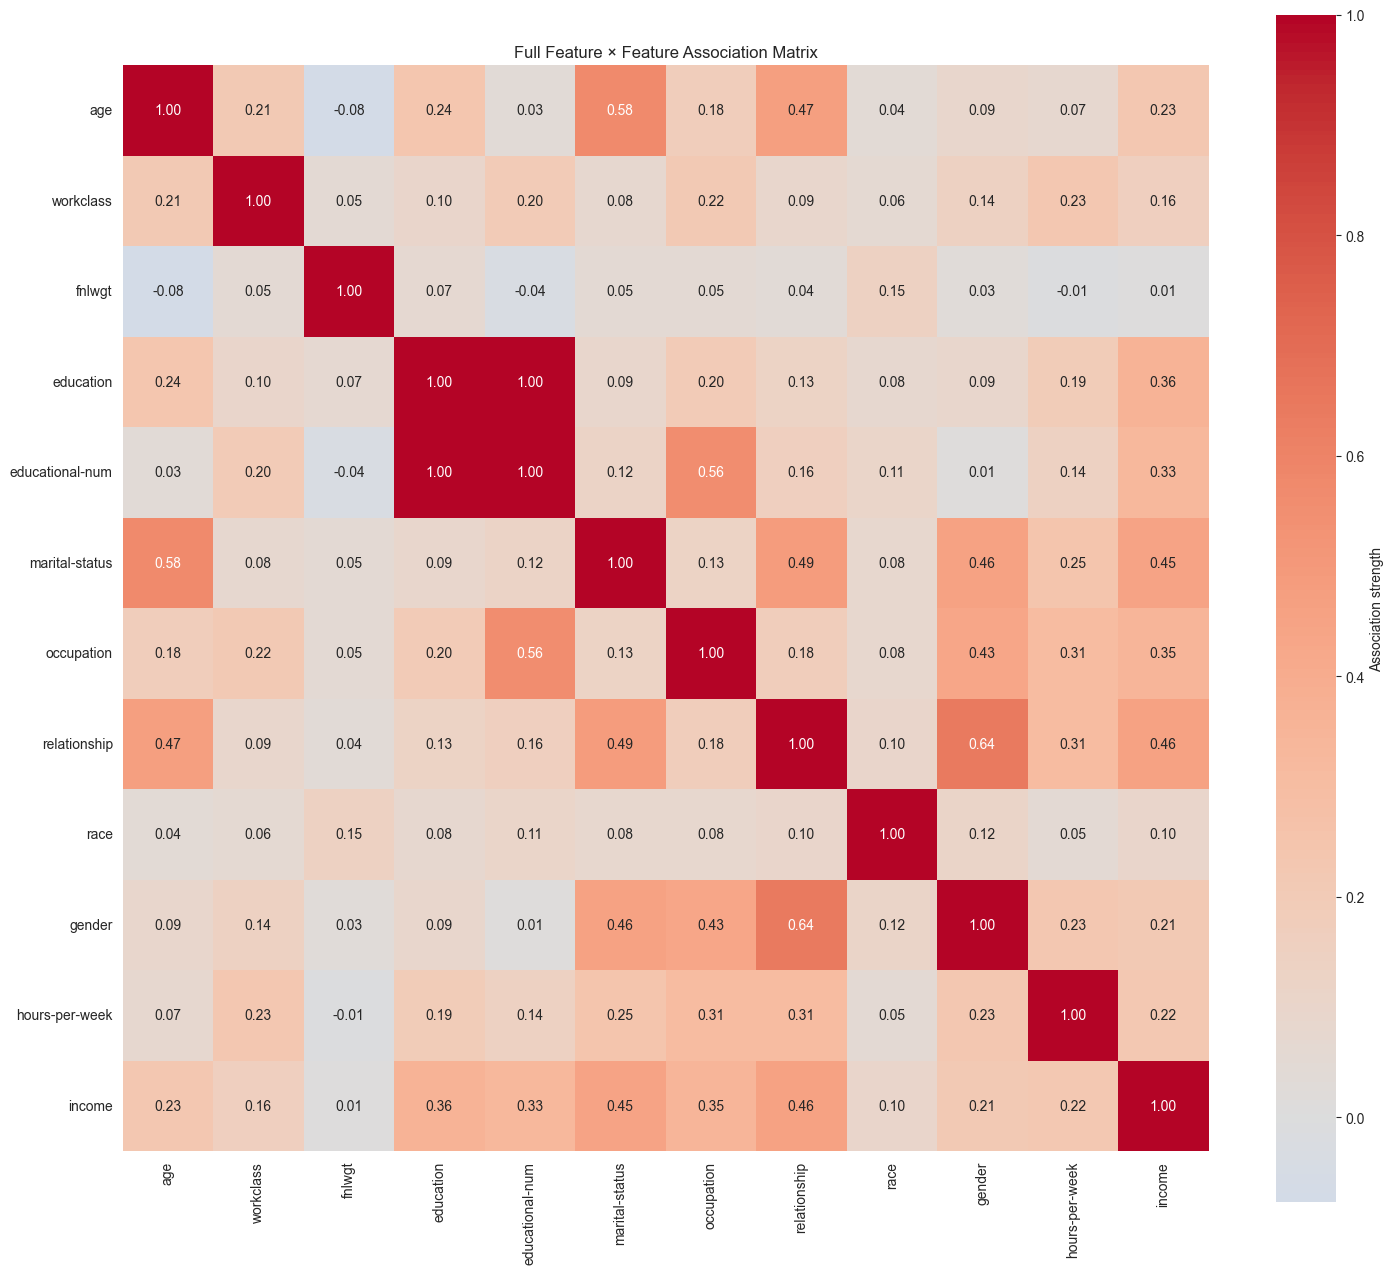

In [15]:
plot_heatmap(df)

In [16]:
df.drop(columns=["education", 'fnlwgt'], inplace=True)

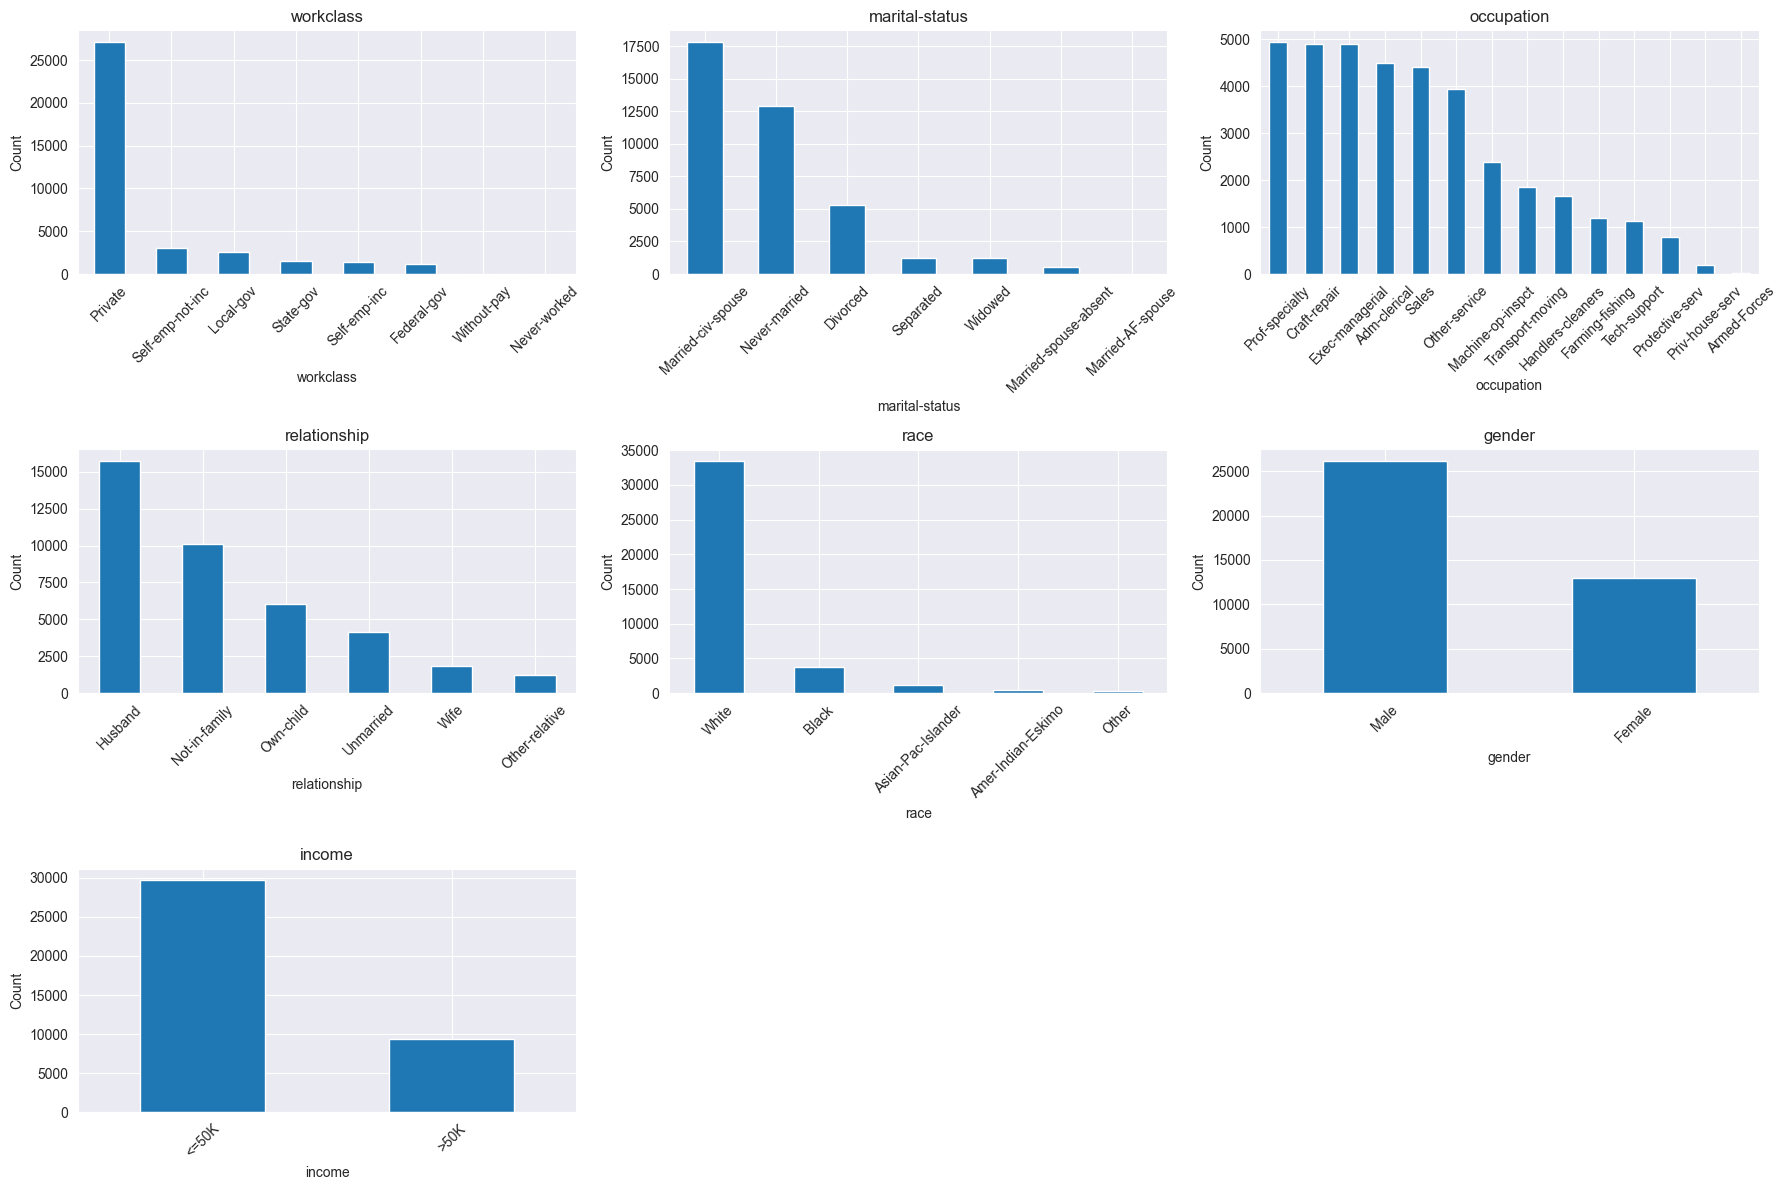

In [17]:
plot_cat(df)

In [18]:
for col in df.select_dtypes(include=["object", "category"]).columns.tolist():
    print(f"\n=== {col} ===")
    pct = df[col].value_counts(normalize=True, dropna=False) * 100

    summary = (pd.DataFrame({"percent": pct.round(2)}).sort_values("percent", ascending=False))

    print(summary)



=== workclass ===
                  percent
workclass                
Private             69.37
Self-emp-not-inc     7.84
Local-gov            6.53
NaN                  5.69
State-gov            4.04
Self-emp-inc         3.51
Federal-gov          2.95
Without-pay          0.04
Never-worked         0.03

=== marital-status ===
                       percent
marital-status                
Married-civ-spouse       45.66
Never-married            33.09
Divorced                 13.58
Separated                 3.17
Widowed                   3.12
Married-spouse-absent     1.29
Married-AF-spouse         0.08

=== occupation ===
                   percent
occupation                
Prof-specialty       12.66
Craft-repair         12.56
Exec-managerial      12.53
Adm-clerical         11.51
Sales                11.31
Other-service        10.11
Machine-op-inspct     6.11
NaN                   5.72
Transport-moving      4.73
Handlers-cleaners     4.27
Farming-fishing       3.07
Tech-support         

In [19]:
threshold = 0.05  # 5%

for col in df.select_dtypes(include=["object", "category"]).columns.tolist():
    value_freq = df[col].value_counts(normalize=True)
    rare_values = value_freq[value_freq < threshold].index

    df[col] = df[col].where(~df[col].isin(rare_values), other="Other")


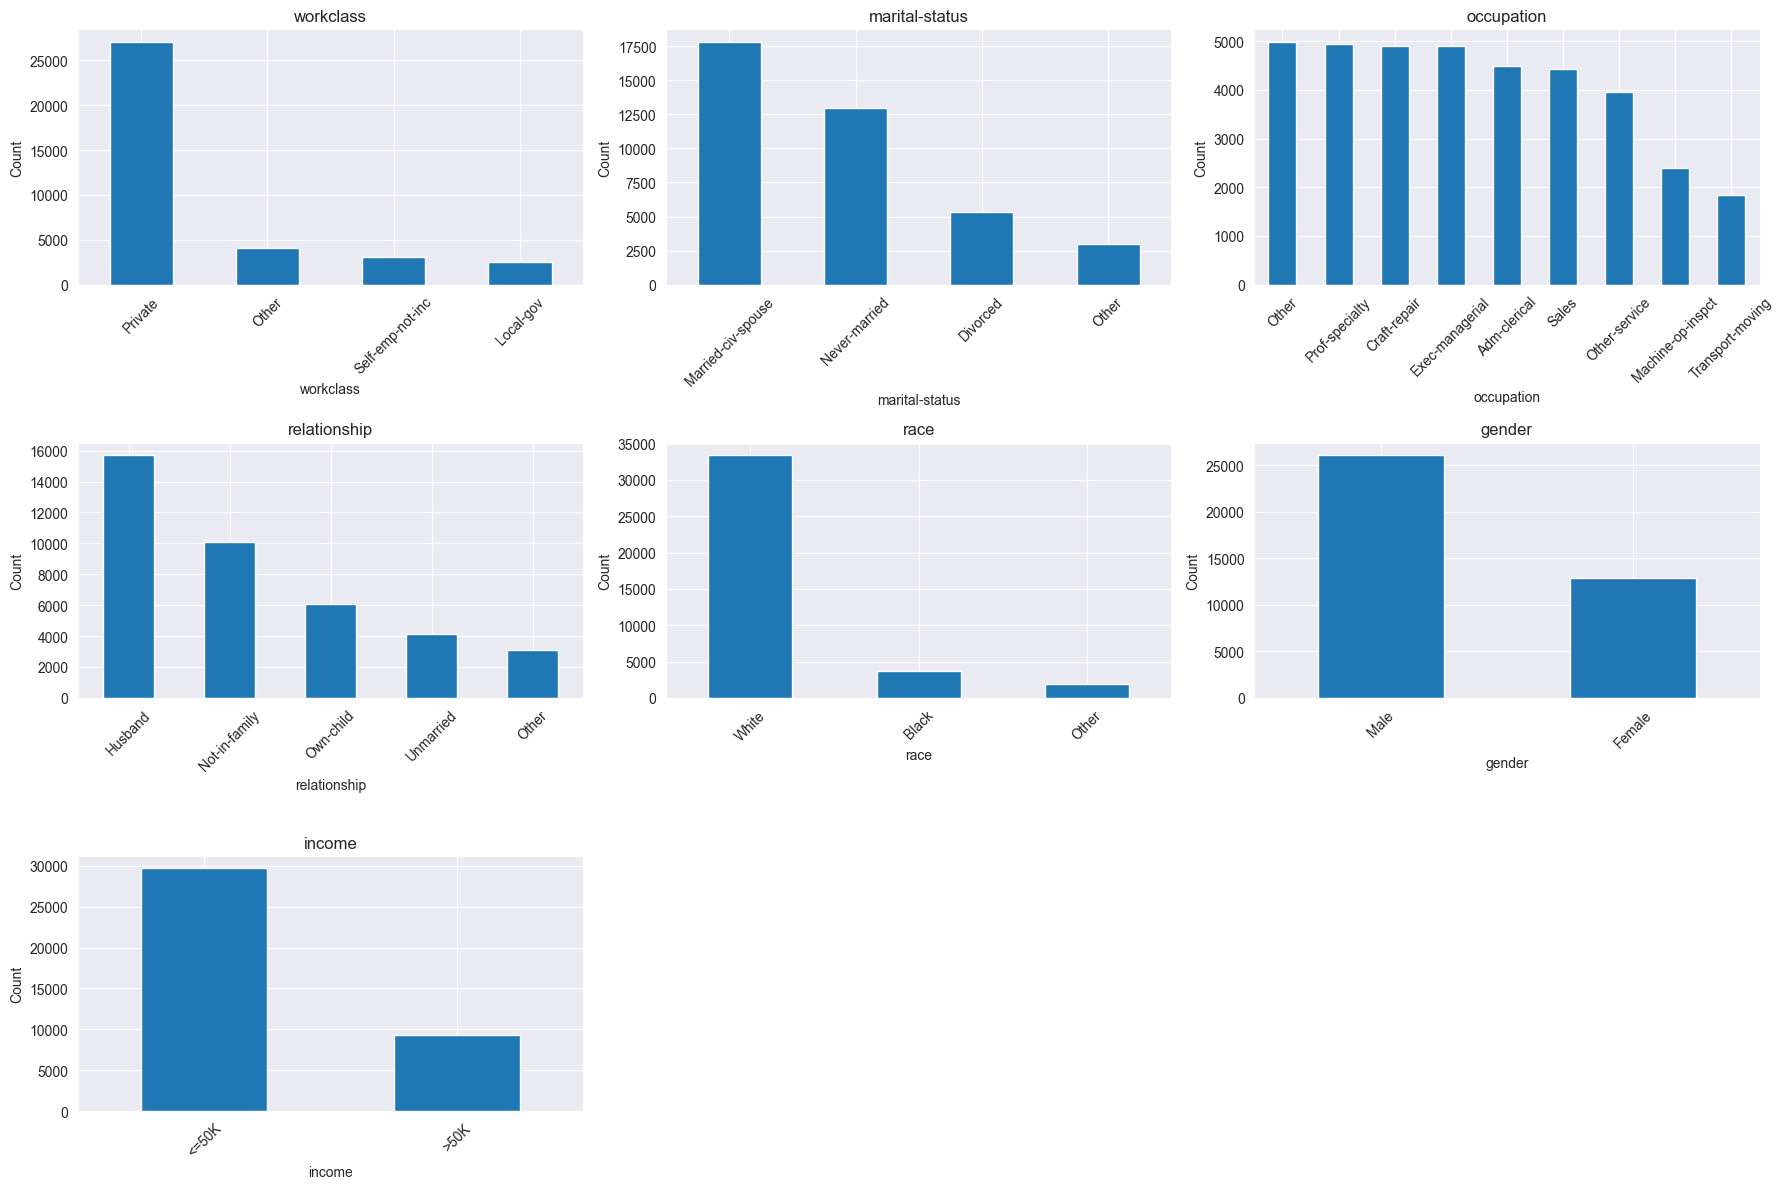

In [20]:
plot_cat(df)

In [21]:
X_train = df.drop(columns=["income"])
y_train = (df["income"] == ">50K").astype(int)

X_test = test_df.drop(columns=["income"])
y_test = (test_df["income"] == ">50K").astype(int)


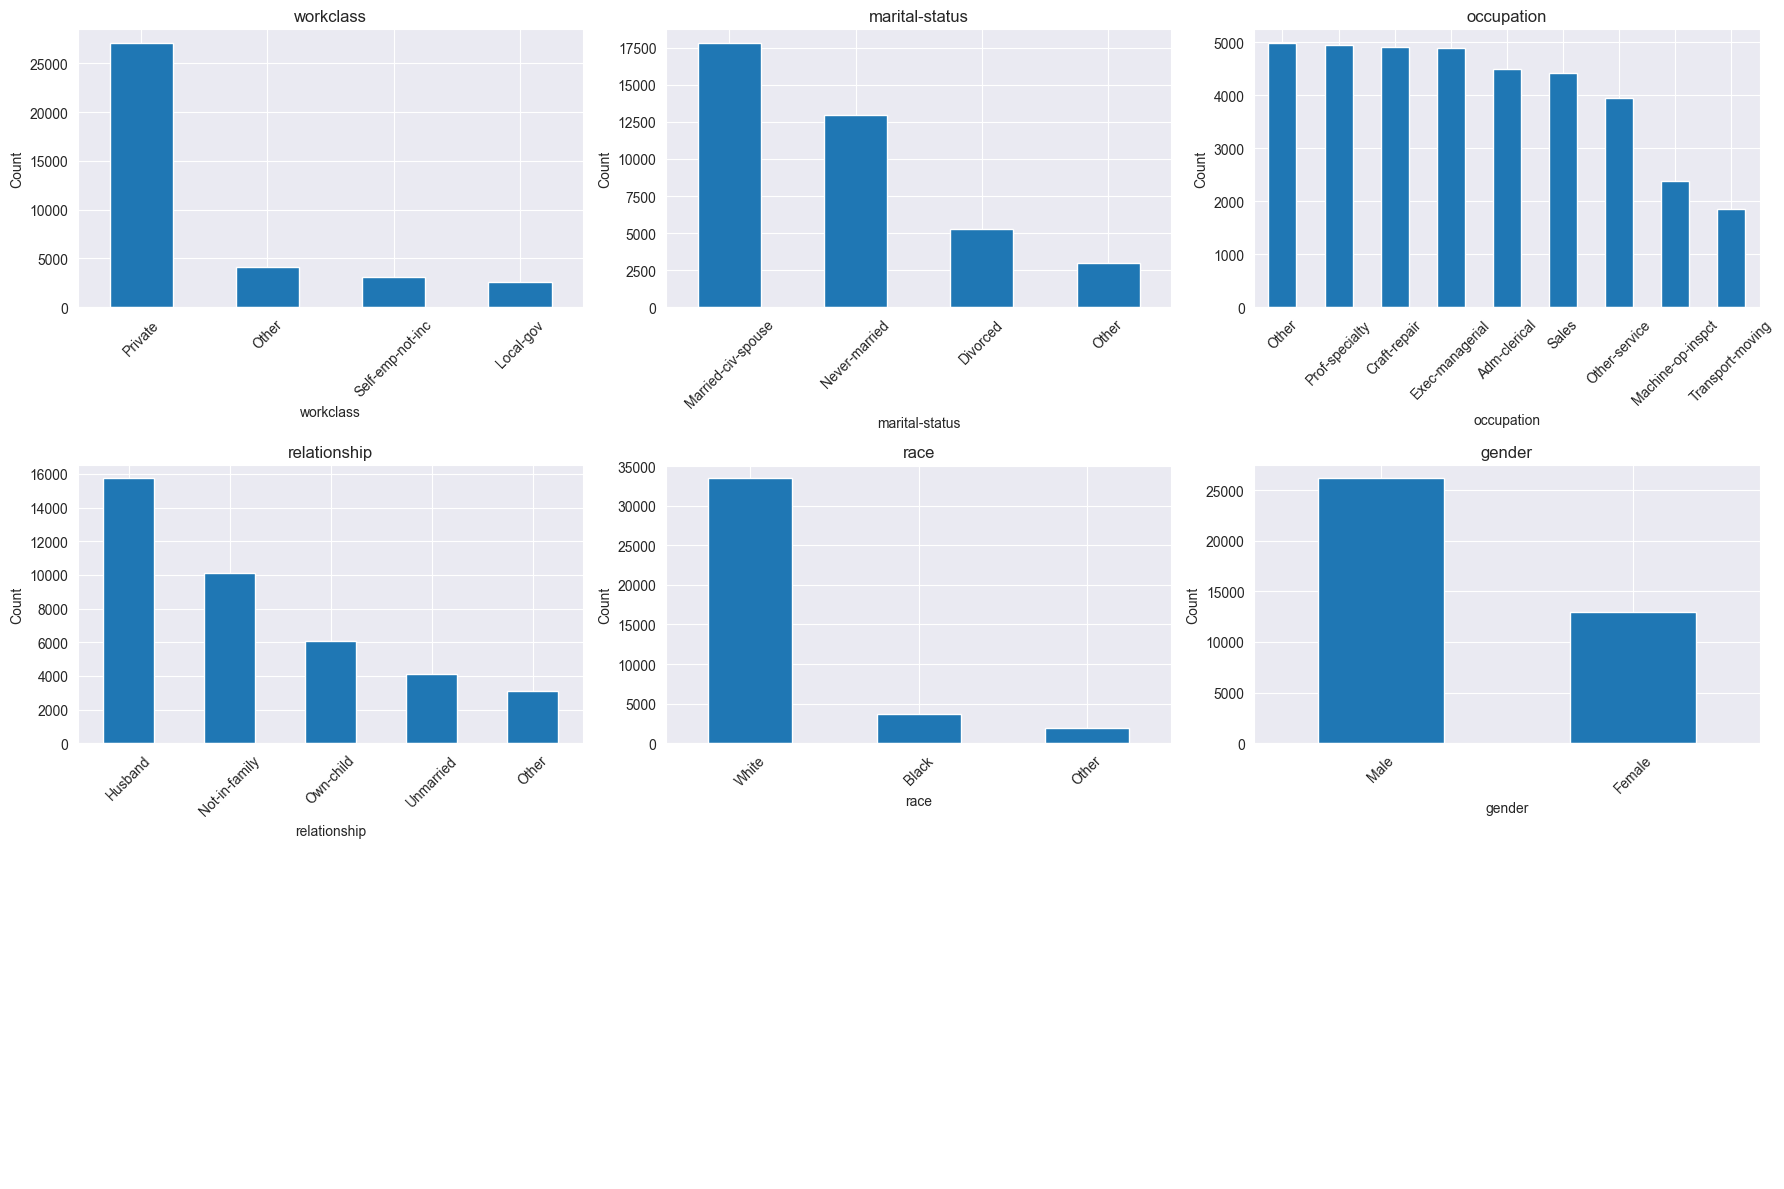

In [22]:
plot_cat(X_train)

### identify numeric vs categorical

In [23]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)


Numerical: ['age', 'educational-num', 'hours-per-week']
Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender']


### numeric imputer (handles missing values)

In [24]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")


median is robust to outliers

### numeric scaler

In [25]:
from sklearn.preprocessing import StandardScaler

num_scaler = StandardScaler()


visualize before and after scaling

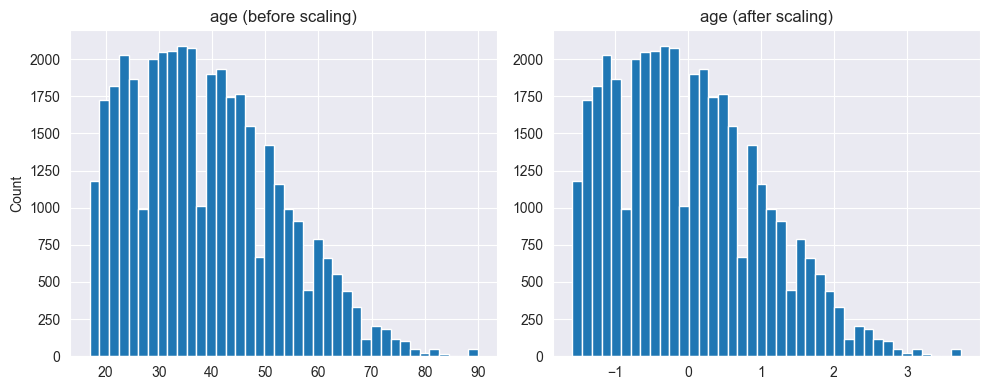

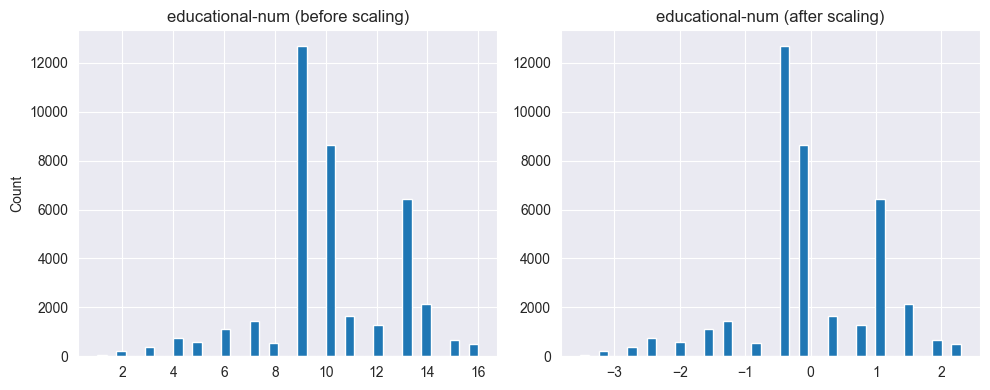

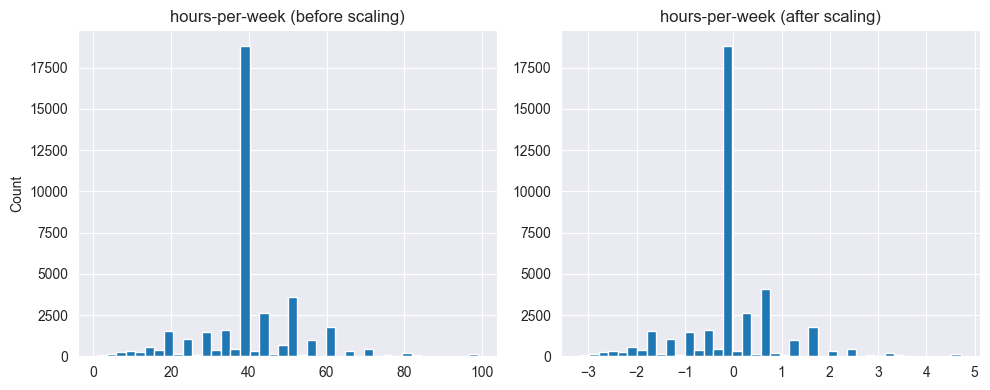

In [26]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_num = X_train[num_cols]

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

X_num_scaled = pd.DataFrame(
    X_num_scaled,
    columns=num_cols,
    index=X_train.index
)

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # before
    axes[0].hist(X_num[col], bins=40)
    axes[0].set_title(f"{col} (before scaling)")
    axes[0].set_ylabel("Count")

    # after
    axes[1].hist(X_num_scaled[col], bins=40)
    axes[1].set_title(f"{col} (after scaling)")

    plt.tight_layout()
    plt.show()


### numeric pipeline (chain the numeric steps)

In [27]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline(steps=[
    ("imputer", num_imputer),
    ("scaler", num_scaler),
])


### categorical imputer

In [28]:
cat_imputer = SimpleImputer(strategy="most_frequent")


categorical missing values → replace with most common category.

### one-hot encoder

In [29]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False
)


### categorical pipeline

In [30]:
cat_pipeline = Pipeline(steps=[
    ("imputer", cat_imputer),
    ("onehot", cat_encoder),
])


### ColumnTransformer (apply the right pipeline to the right columns)

In [31]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ],
    remainder="drop"   # keep only what we specify
)


### fit/transform (sanity check result)

In [32]:
X_processed = preprocessor.fit_transform(X_train)
print("Before preprocessing:", df.shape)
print("Processed shape:", X_processed.shape)

Before preprocessing: (39073, 10)
Processed shape: (39073, 29)


In [33]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Check scale actually worked

In [34]:
print(f"preprocessed mean: {X_processed.mean(axis=0)}\n")
print(f"preprocessed std: {X_processed.std(axis=0)}")

preprocessed mean: [-1.84819330e-16  1.59596158e-16 -6.85369786e-16  6.53136437e-02
  1.05648402e-01  7.50646226e-01  7.83917283e-02  1.35822691e-01
  4.56632457e-01  3.30944642e-01  7.66002099e-02  1.15066670e-01
  1.25585443e-01  1.25278325e-01  6.10907788e-02  1.84884703e-01
  1.01144012e-01  1.26557981e-01  1.13121593e-01  4.72704937e-02
  4.02579787e-01  2.58618483e-01  7.86732526e-02  1.54889566e-01
  1.05238912e-01  9.51296292e-02  4.87804878e-02  8.56089883e-01
  6.69004172e-01]

preprocessed std: [1.         1.         1.         0.24707847 0.30738708 0.43263896
 0.26878703 0.34260019 0.49811571 0.47055317 0.26595604 0.31910238
 0.33138156 0.33103424 0.23949675 0.38820401 0.30151932 0.33247716
 0.31674137 0.21221686 0.49041748 0.43787551 0.2692281  0.36179938
 0.30686102 0.2933939  0.2154088  0.35099857 0.47057156]


### Plot corr of each new feature w.r.t. y

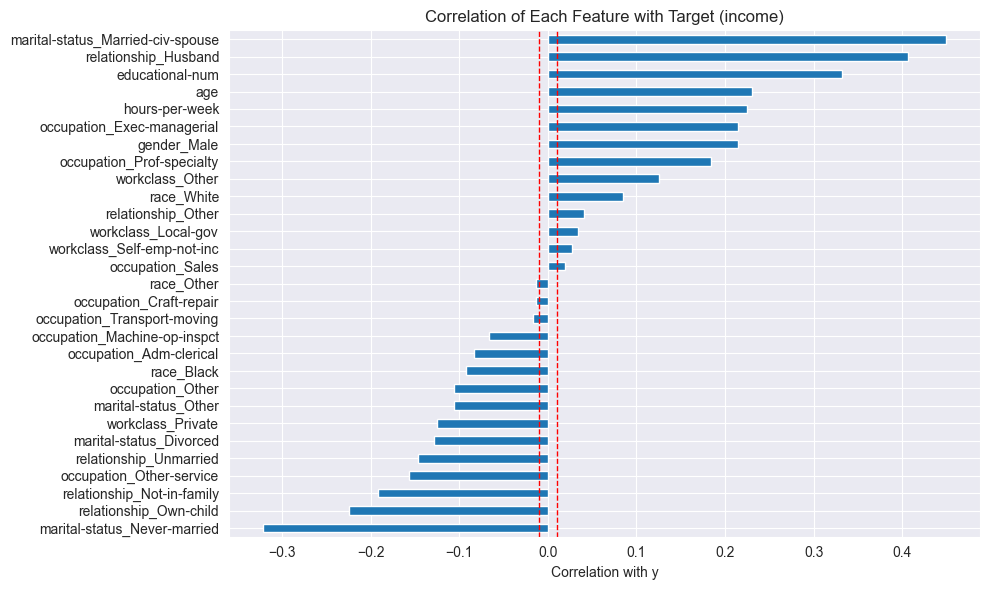

In [35]:
# get feature names after preprocessing
num_features = num_cols

cat_features = (
    preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(cat_cols)
)

feature_names = list(num_features) + list(cat_features)

corr_with_y = pd.Series(
    np.corrcoef(X_processed, y_train, rowvar=False)[-1, :-1],
    index=feature_names
).sort_values()

plt.figure(figsize=(10, 6))
corr_with_y.plot(kind="barh")
plt.axvline(0.01, color="red", linestyle="--", linewidth=1)
plt.axvline(-0.01, color="red", linestyle="--", linewidth=1)
plt.title("Correlation of Each Feature with Target (income)")
plt.xlabel("Correlation with y")
plt.tight_layout()
plt.show()


## Fit model

### We want to compare SVM to LR

to do this, we would train the best model we can and then compare them

### LogisticRegression

Define the pipeline

In [36]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000
    ))
])


In [37]:
pipe_lr

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Define the random search space

In [38]:
from scipy.stats import loguniform

param_dist_lr = [
    {
        "clf__penalty": ["l1", "l2"],
        "clf__C": loguniform(1e-3, 1e2),
        "clf__class_weight": [None, "balanced"],
    },
    {
        "clf__penalty": ["elasticnet"],
        "clf__C": loguniform(1e-3, 1e2),
        "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        "clf__class_weight": [None, "balanced"],
    }
]


Question: What would happen if someone split their data after we put the data into the pipeline?

In [39]:
# from sklearn.model_selection import train_test_split
#
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )


Run RandomizedSearchCV

In [40]:
from sklearn.model_selection import RandomizedSearchCV

rand_search_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist_lr,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rand_search_lr.fit(X_train, y_train)


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/regev32/.pyenv/versions/3.11.9/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/regev32/.pyenv/versions/3.11.9/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/regev32/.pyenv/versions/3.11.9/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

,estimator,Pipeline(step...ver='saga'))])
,param_distributions,"[{'clf__C': <scipy.stats....t 0x154b01c50>, 'clf__class_weight': [None, 'balanced'], 'clf__penalty': ['l1', 'l2']}, {'clf__C': <scipy.stats....t 0x152313150>, 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.1, 0.3, ...], 'clf__penalty': ['elasticnet']}]"
,n_iter,40
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


Freeze this LR model

In [41]:
best_lr = rand_search_lr.best_estimator_


we don't need to pass the test set through the pipeline, it's build in our model!

In [42]:
best_lr

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


/Users/regev32/PycharmProjects/Intro-to-artificial-intelligence/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


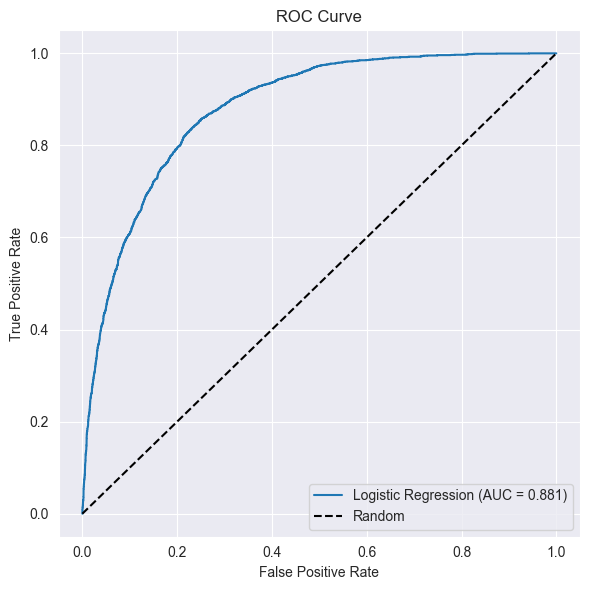

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

# predict probabilities for the positive class
y_score = best_lr.predict_proba(X_test)[:, 1]

# ROC components
fpr, tpr, _ = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

# plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### SVM

Pipeline

In [44]:
from sklearn.svm import LinearSVC

pipe_svm = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LinearSVC(
        max_iter=500000,
        dual="auto"   # sklearn decides optimal dual/primal
    ))
])


Hyperparameter search space

In [45]:
param_dist_svm = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__loss": ["hinge", "squared_hinge"],
    "clf__class_weight": [None, "balanced"]
}


RandomizedSearchCV

In [46]:
rand_search_svm = RandomizedSearchCV(
    estimator=pipe_svm,
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)

rand_search_svm.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...ter=500000))])
,param_distributions,"{'clf__C': <scipy.stats....t 0x154c2ba90>, 'clf__class_weight': [None, 'balanced'], 'clf__loss': ['hinge', 'squared_hinge']}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [47]:
best_svm = rand_search_svm.best_estimator_


/Users/regev32/PycharmProjects/Intro-to-artificial-intelligence/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


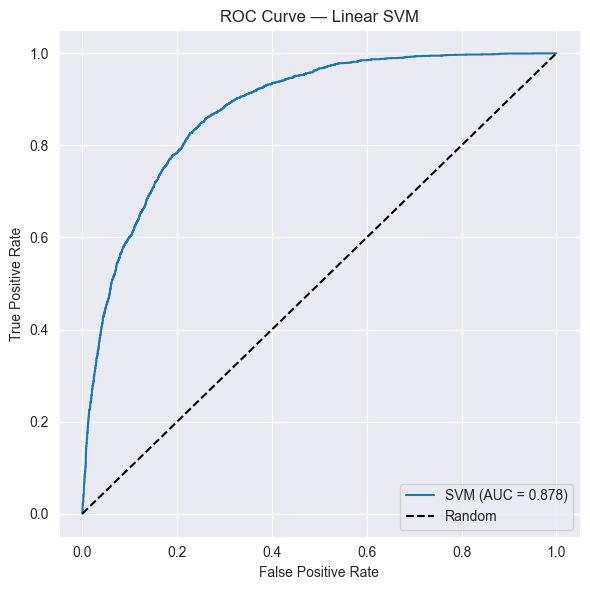

In [48]:
# decision scores
y_score_svm = best_svm.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score_svm)
auc = roc_auc_score(y_test, y_score_svm)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Linear SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


/Users/regev32/PycharmProjects/Intro-to-artificial-intelligence/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/regev32/PycharmProjects/Intro-to-artificial-intelligence/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


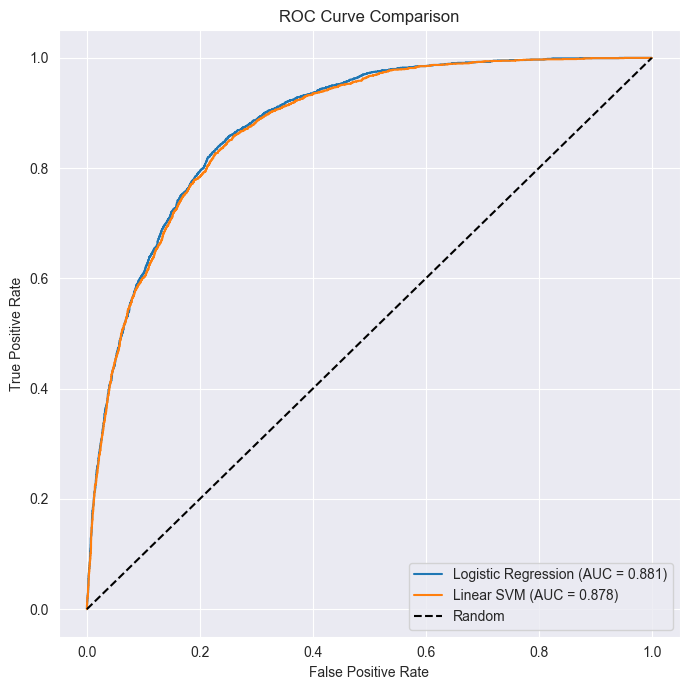

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 7))

# ---- Logistic Regression ----
y_score_lr = best_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_lr = roc_auc_score(y_test, y_score_lr)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")


# ---- Linear SVM ----
y_score_svm = best_svm.decision_function(X_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = roc_auc_score(y_test, y_score_svm)

plt.plot(fpr_svm, tpr_svm, label=f"Linear SVM (AUC = {auc_svm:.3f})")


# ---- Random baseline ----
plt.plot([0, 1], [0, 1], "k--", label="Random")


# ---- Plot formatting ----
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
final_model = best_lr


## Comparing our pipeline

In [51]:
df_raw = pd.read_csv(
    "adult.csv",
    na_values="?"
)


In [52]:
# drop missing rows (minimal, not optimal)
df_raw = df_raw.dropna()

# target
y_default = (df_raw["income"] == ">50K").astype(int)
X_default = df_raw.drop(columns=["income"])

X_default_train, X_default_test, y_default_train, y_default_test = train_test_split(
    X_default, y_default, test_size=0.2, random_state=42
)
num_cols = X_default_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_default_train.select_dtypes(include=["object"]).columns

preprocessor_default = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


In [53]:
default_lr = Pipeline([
    ("preprocess", preprocessor_default),
    ("clf", LogisticRegression(max_iter=1))  # all defaults
])

default_lr.fit(X_default_train, y_default_train)


/Users/regev32/PycharmProjects/Intro-to-artificial-intelligence/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


/Users/regev32/PycharmProjects/Intro-to-artificial-intelligence/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


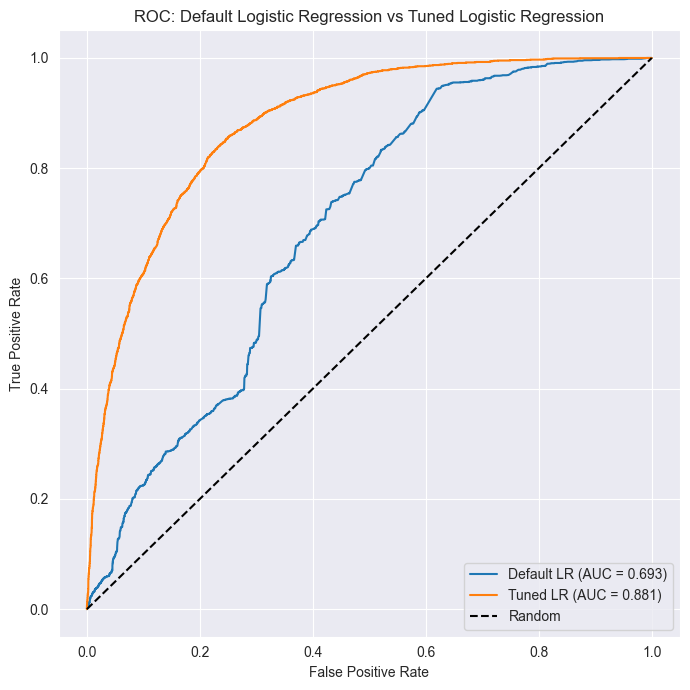

In [54]:
# ----- Default LR -----
y_score_default = default_lr.predict_proba(X_default_test)[:, 1]
fpr_d, tpr_d, _ = roc_curve(y_default_test, y_score_default)
auc_d = roc_auc_score(y_default_test, y_score_default)

# ----- Tuned LR -----
y_score_tuned = best_lr.predict_proba(X_test)[:, 1]
fpr_t, tpr_t, _ = roc_curve(y_test, y_score_tuned)
auc_t = roc_auc_score(y_test, y_score_tuned)

# ----- Plot -----
plt.figure(figsize=(7, 7))
plt.plot(fpr_d, tpr_d, label=f"Default LR (AUC = {auc_d:.3f})")
plt.plot(fpr_t, tpr_t, label=f"Tuned LR (AUC = {auc_t:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Default Logistic Regression vs Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
